# 1. Data Check — Credit Card Fraud Detection

**Objective:** Verify the raw dataset is intact, understand its structure, and quantify the class imbalance before any modeling.

> **Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
> The dataset contains 284,807 credit card transactions made by European cardholders in September 2013.  
> Features `V1`–`V28` are PCA-transformed (anonymized). `Time`, `Amount`, and `Class` are the original columns.


In [12]:
# ── Core imports ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Libraries loaded ✓")


Libraries loaded ✓


## 1.1 Load Raw Dataset

In [13]:
from pathlib import Path

DATA_PATH = Path("../data/raw/creditcard.csv")

df = pd.read_csv(DATA_PATH)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print()
df.head()


Rows    : 284,807
Columns : 31



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 1.2 Column Overview

In [14]:
# Column names grouped by type
pca_cols   = [c for c in df.columns if c.startswith("V")]
other_cols = [c for c in df.columns if not c.startswith("V")]

print("Non-PCA columns :", other_cols)
print(f"PCA features    : {pca_cols[0]} … {pca_cols[-1]}  ({len(pca_cols)} total)")


Non-PCA columns : ['Time', 'Amount', 'Class']
PCA features    : V1 … V28  (28 total)


## 1.3 Data Types & Memory Usage

In [15]:
# dtypes + memory
info = pd.DataFrame({
    "dtype"        : df.dtypes,
    "non_null"     : df.notna().sum(),
    "null_count"   : df.isna().sum(),
    "null_pct"     : (df.isna().mean() * 100).round(4),
    "unique"       : df.nunique(),
})
info


,dtype,non_null,null_count,null_pct,unique
Time,float64,284807,0,0.0000,124592
V1,float64,284807,0,0.0000,275663
V2,float64,284807,0,0.0000,275663
V3,float64,284807,0,0.0000,275663
V4,float64,284807,0,0.0000,275663
V5,float64,284807,0,0.0000,275663
V6,float64,284807,0,0.0000,275663
V7,float64,284807,0,0.0000,275663
V8,float64,284807,0,0.0000,275663
V9,float64,284807,0,0.0000,275663


## 1.4 Missing Values

In [16]:
missing = df.isna().sum()
total_missing = missing.sum()

if total_missing == 0:
    print("✅  No missing values found. Dataset is complete.")
else:
    print(f"⚠️  {total_missing} missing values detected:")
    print(missing[missing > 0])


✅  No missing values found. Dataset is complete.


## 1.5 Duplicate Rows

In [17]:
dup_count = df.duplicated().sum()
dup_pct   = dup_count / len(df) * 100

print(f"Duplicate rows : {dup_count:,}  ({dup_pct:.4f}%)")

if dup_count > 0:
    print("\nSample duplicates:")
    display(df[df.duplicated(keep=False)].head(6))
else:
    print("✅  No duplicate rows.")


Duplicate rows : 1,081  (0.3796%)

Sample duplicates:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0000,-0.5299,0.8739,1.3472,0.1455,0.4142,0.1002,0.7112,0.1761,-0.2867,-0.4847,0.8725,0.8516,-0.5717,0.1010,-1.5198,-0.2844,-0.3105,-0.4042,-0.8234,-0.2903,0.0469,0.2081,-0.1855,0.0010,0.0988,-0.5529,-0.0733,0.0233,6.1400,0
33,26.0000,-0.5299,0.8739,1.3472,0.1455,0.4142,0.1002,0.7112,0.1761,-0.2867,-0.4847,0.8725,0.8516,-0.5717,0.1010,-1.5198,-0.2844,-0.3105,-0.4042,-0.8234,-0.2903,0.0469,0.2081,-0.1855,0.0010,0.0988,-0.5529,-0.0733,0.0233,6.1400,0
34,26.0000,-0.5354,0.8653,1.3511,0.1476,0.4337,0.0870,0.6930,0.1797,-0.2856,-0.4825,0.8718,0.8534,-0.5718,0.1023,-1.5200,-0.2859,-0.3096,-0.4039,-0.8237,-0.2833,0.0495,0.2065,-0.1871,0.0008,0.0981,-0.5535,-0.0783,0.0254,1.7700,0
35,26.0000,-0.5354,0.8653,1.3511,0.1476,0.4337,0.0870,0.6930,0.1797,-0.2856,-0.4825,0.8718,0.8534,-0.5718,0.1023,-1.5200,-0.2859,-0.3096,-0.4039,-0.8237,-0.2833,0.0495,0.2065,-0.1871,0.0008,0.0981,-0.5535,-0.0783,0.0254,1.7700,0
112,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0
113,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0


## 1.6 Class Distribution (Target Variable)

In [18]:
# Raw counts
class_counts = df["Class"].value_counts().sort_index()
class_pcts   = df["Class"].value_counts(normalize=True).sort_index() * 100

normal_n = class_counts[0]
fraud_n  = class_counts[1]
ratio    = round(normal_n / fraud_n)

print("Class value counts:")
print(class_counts)
print()
print(f"Normal (0) : {normal_n:>7,}  ({class_pcts[0]:.4f}%)")
print(f"Fraud  (1) : {fraud_n:>7,}  ({class_pcts[1]:.4f}%)")
print(f"\nImbalance ratio : ~1 fraud per {ratio:,} normal transactions")


Class value counts:
Class
0    284315
1       492
Name: count, dtype: int64

Normal (0) : 284,315  (99.8273%)
Fraud  (1) :     492  (0.1727%)

Imbalance ratio : ~1 fraud per 578 normal transactions


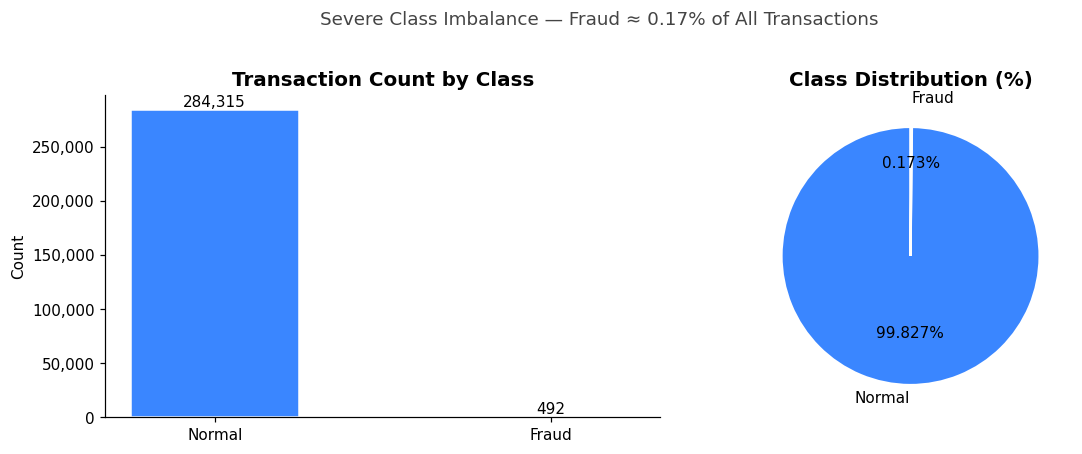

In [19]:
# ── Visualise class imbalance ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar — raw counts
axes[0].bar(["Normal", "Fraud"], class_counts.values,
            color=["#3a86ff", "#ff006e"], edgecolor="white", width=0.5)
axes[0].set_title("Transaction Count by Class", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{val:,}", ha="center", va="bottom", fontsize=10)

# Pie — percentage
axes[1].pie(class_counts.values,
            labels=["Normal", "Fraud"],
            autopct="%1.3f%%",
            colors=["#3a86ff", "#ff006e"],
            startangle=90,
            explode=(0, 0.12),
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Class Distribution (%)", fontsize=13, fontweight="bold")

plt.suptitle("Severe Class Imbalance — Fraud ≈ 0.17% of All Transactions",
             fontsize=12, y=1.02, color="#444")
plt.tight_layout()
plt.show()


## 1.7 Basic Descriptive Statistics

In [20]:
# Summary stats for non-PCA columns
df[["Time", "Amount", "Class"]].describe()


,Time,Amount,Class
count,284807.0000,284807.0000,284807.0000
mean,94813.8596,88.3496,0.0017
std,47488.1460,250.1201,0.0415
min,0.0000,0.0000,0.0000
25%,54201.5000,5.6000,0.0000
50%,84692.0000,22.0000,0.0000
75%,139320.5000,77.1650,0.0000
max,172792.0000,25691.1600,1.0000


In [21]:
# Amount quantiles for fraud vs normal
amount_summary = df.groupby("Class")["Amount"].describe()
amount_summary.index = ["Normal", "Fraud"]
amount_summary


,count,mean,std,min,25%,50%,75%,max
Normal,284315.0000,88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,25691.1600
Fraud,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,2125.8700


## 1.8 Data Check — Quick Health Report

In [22]:
print("=" * 50)
print("  DATA HEALTH REPORT")
print("=" * 50)
print(f"  Total rows       : {len(df):,}")
print(f"  Total columns    : {df.shape[1]}")
print(f"  Missing values   : {df.isna().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum():,}")
print(f"  PCA features     : {len(pca_cols)}")
print(f"  Normal txns      : {normal_n:,} ({class_pcts[0]:.3f}%)")
print(f"  Fraud txns       : {fraud_n:,} ({class_pcts[1]:.3f}%)")
print(f"  Imbalance ratio  : 1 : {ratio:,}")
print("=" * 50)


  DATA HEALTH REPORT
  Total rows       : 284,807
  Total columns    : 31
  Missing values   : 0
  Duplicate rows   : 1,081
  PCA features     : 28
  Normal txns      : 284,315 (99.827%)
  Fraud txns       : 492 (0.173%)
  Imbalance ratio  : 1 : 578


## Summary

| Check | Result |
|---|---|
| Missing values | None |
| Duplicate rows | 1,081 (0.38%) — present, will be addressed in preprocessing |
| Feature types | 28 PCA features + Time + Amount (all float64) |
| Target column | `Class` — binary (0 = Normal, 1 = Fraud) |
| Class imbalance | Extreme — fraud is only ~0.17% of transactions |

**Key takeaway for modeling:**  
Accuracy alone will be misleading on this dataset. A model that always predicts *normal* would still achieve ~99.83% accuracy while catching zero fraud. The project must use fraud-focused metrics:
- **Precision** — of predicted frauds, how many are real?
- **Recall** — of real frauds, how many did we catch?
- **F1-score** — harmonic mean of precision and recall
- **PR-AUC** — area under the precision-recall curve (most important for imbalanced data)
- **ROC-AUC** — area under the ROC curve

**Next step →** `2_eda.ipynb` — Exploratory Data Analysis
